### GaussianProcessRegressor

In [27]:
import numpy as np

class GaussianProcessRegressor:
    def __init__(self, length_scale=1.0, signal_variance=1.0, noise_variance=1e-6):
        '''
        Initializes the GaussianProcessRegressor with hyperparameters.

        Args:
            length_scale (float): The characteristic length scale of the RBF kernel (l).
            signal_variance (float): The signal variance of the RBF kernel (sigma_f).
            noise_variance (float): The noise variance (sigma_n).
        '''
        self.length_scale = length_scale
        self.signal_variance = signal_variance
        self.noise_variance = noise_variance
        self.X_train = None
        self.y_train = None
        self.K_inv = None # Inverse of the kernel matrix for training data
        print("GaussianProcessRegressor initialized.")

    def mean_function(self, X):
        '''
        Defines the mean function of the GP. For simplicity, returns an array of zeros.

        Args:
            X (np.ndarray): Input points of shape (n_samples, n_features).

        Returns:
            np.ndarray: An array of zeros of shape (n_samples,).
        '''
        return np.zeros(X.shape[0])
        print("Mean function defined as zero function.")

    def rbf_kernel(self, X1, X2):
        '''
        Computes the Radial Basis Function (RBF) kernel matrix between two input arrays.

        Args:
            X1 (np.ndarray): First input array of shape (n_samples1, n_features).
            X2 (np.ndarray): Second input array of shape (n_samples2, n_features).

        Returns:
            np.ndarray: The RBF kernel matrix of shape (n_samples1, n_samples2).
        '''
        sq_dist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
        return self.signal_variance * np.exp(-0.5 * sq_dist / (self.length_scale**2))
        print("RBF kernel computed.")

    def fit(self, X_train, y_train):
        '''
        Stores training data and computes the inverse of the kernel matrix.

        Args:
            X_train (np.ndarray): Training input data of shape (n_samples, n_features).
            y_train (np.ndarray): Training output data of shape (n_samples,).
        '''
        self.X_train = X_train
        self.y_train = y_train

        # Compute kernel matrix for training data
        K = self.rbf_kernel(X_train, X_train)
        # Add noise variance to the diagonal for numerical stability
        K += self.noise_variance * np.eye(len(X_train))

        # Compute the inverse of the kernel matrix
        self.K_inv = np.linalg.inv(K)
        print("Model fitted and K_inv computed.")

    def predict(self, X_test):
        '''
        Predicts the mean and standard deviation for new input points.

        Args:
            X_test (np.ndarray): New input points of shape (n_samples, n_features).

        Returns:
            tuple: A tuple containing:
                - mean (np.ndarray): Predictive mean of shape (n_samples,).
                - std (np.ndarray): Predictive standard deviation of shape (n_samples,).
        '''
        if self.X_train is None or self.y_train is None or self.K_inv is None:
            raise RuntimeError("Model has not been fitted. Call fit() first.")

        # Compute kernel matrices
        K_star = self.rbf_kernel(self.X_train, X_test)  # K(X_train, X_test)
        K_star_star = self.rbf_kernel(X_test, X_test)  # K(X_test, X_test)

        # Compute predictive mean
        mean = self.mean_function(X_test) + K_star.T @ self.K_inv @ (self.y_train - self.mean_function(self.X_train))

        # Compute predictive covariance (including noise for the diagonal, but excluding it for K_star_star in the formula)
        covariance = K_star_star - K_star.T @ self.K_inv @ K_star

        # For numerical stability, ensure diagonal elements are non-negative
        variance = np.maximum(0, np.diag(covariance))
        std = np.sqrt(variance)

        print("Prediction completed.")
        return mean, std

    def sample_posterior(self, X_test, n_samples=1):
        '''
        Samples from the posterior predictive distribution for new input points.

        Args:
            X_test (np.ndarray): New input points of shape (n_samples_test, n_features).
            n_samples (int): Number of samples to draw from the posterior.

        Returns:
            np.ndarray: An array of shape (n_samples, n_samples_test) containing samples
                        from the posterior distribution.
        '''
        if self.X_train is None or self.y_train is None or self.K_inv is None:
            raise RuntimeError("Model has not been fitted. Call fit() first.")

        # Compute predictive mean and covariance matrix
        # Note: We need the full covariance matrix for sampling, not just the diagonal variances
        K_star = self.rbf_kernel(self.X_train, X_test)
        K_star_star = self.rbf_kernel(X_test, X_test)

        mean = self.mean_function(X_test) + K_star.T @ self.K_inv @ (self.y_train - self.mean_function(self.X_train))
        covariance = K_star_star - K_star.T @ self.K_inv @ K_star

        # Add a small value to the diagonal for numerical stability, especially for sampling
        # This prevents potential issues with non-positive definite covariance matrices
        covariance += 1e-6 * np.eye(covariance.shape[0])

        # Draw samples from the multivariate normal distribution
        samples = np.random.multivariate_normal(mean, covariance, n_samples)

        print(f"Generated {n_samples} posterior samples.")
        return samples


Generate 1D synthetic data (X, y) with a non-linear underlying function (e.g., sine wave) and add Gaussian noise to the target variable (y).


In [28]:
import numpy as np

# 1. Define a non-linear underlying function (e.g., sine wave)
def true_function(x):
    return np.sin(x) * 2 + x * 0.5

# Parameters for data generation
X_start = -5
X_end = 5
num_train_points = 50
noise_std = 0.5

# 2. Generate 1D input data points for training, X_train
X_train = np.linspace(X_start, X_end, num_train_points).reshape(-1, 1)

# 3. Compute the corresponding true output values, y_true
y_true = true_function(X_train)

# 4. Add Gaussian noise to y_true to create y_train
noise = np.random.normal(0, noise_std, X_train.shape)
y_train = y_true + noise

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (50, 1)
y_train shape: (50, 1)


Generate a separate, denser set of 1D input data points for prediction and plotting, X_test, covering a slightly wider range than X_train and with more points.



In [29]:
import numpy as np

# Parameters for data generation
X_start_test = -6
X_end_test = 6
num_test_points = 200

# 5. Generate a separate, denser set of 1D input data points for prediction and plotting, X_test
X_test = np.linspace(X_start_test, X_end_test, num_test_points).reshape(-1, 1)

print(f"X_test shape: {X_test.shape}")

X_test shape: (200, 1)


Train GPR Model and Predict


In [30]:
gpr_model = GaussianProcessRegressor(
    length_scale=1.0,
    signal_variance=1.0,
    noise_variance=noise_std**2 # Using the noise_std from data generation
)

# Fit the GPR model to the synthetic training data
gpr_model.fit(X_train, y_train.flatten()) # Flatten y_train to make it 1D

# Predict the mean and standard deviation for new input points
y_pred_mean, y_pred_std = gpr_model.predict(X_test)

print(f"Predictive mean shape: {y_pred_mean.shape}")
print(f"Predictive standard deviation shape: {y_pred_std.shape}")

GaussianProcessRegressor initialized.
Model fitted and K_inv computed.
Prediction completed.
Predictive mean shape: (200,)
Predictive standard deviation shape: (200,)


Draw samples from the posterior distribution using the sample_posterior method of the gpr_model and store them.



In [31]:
n_posterior_samples = 5
posterior_samples = gpr_model.sample_posterior(X_test, n_samples=n_posterior_samples)

print(f"Posterior samples shape: {posterior_samples.shape}")

Generated 5 posterior samples.
Posterior samples shape: (5, 200)


Visualize the GPR model's performance



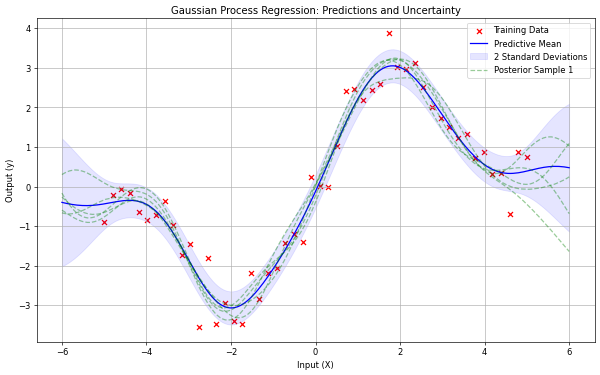

In [33]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
plt.figure(figsize=(12, 7), dpi=60)

# Plot the synthetic training data points
plt.scatter(X_train, y_train, c='red', marker='x', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, y_pred_mean, color='blue', label='Predictive Mean')

# Fill the area representing the uncertainty (2 standard deviations)
plt.fill_between(
    X_test.flatten(),
    (y_pred_mean - 2 * y_pred_std),
    (y_pred_mean + 2 * y_pred_std),
    color='blue', alpha=0.1, label='2 Standard Deviations'
)

# Plot each of the posterior samples
for i, sample in enumerate(posterior_samples):
    plt.plot(X_test, sample, color='green', alpha=0.4, linestyle='--',
             label=f'Posterior Sample {i+1}' if i == 0 else "") # Label only the first sample for clarity

# Set labels, title, and legend
plt.xlabel('Input (X)')
plt.ylabel('Output (y)')
plt.title('Gaussian Process Regression: Predictions and Uncertainty')
plt.legend()
plt.grid(True)
plt.show()